In [13]:
import torch
print("PyTorch version:", torch.__version__)
print("CUDA version used to compile PyTorch:", torch.version.cuda)
print("Is CUDA available?", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
print("Device name (if available):", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A")


PyTorch version: 2.7.0+cpu
CUDA version used to compile PyTorch: None
Is CUDA available? False
CUDA device count: 0
Device name (if available): N/A


In [11]:
import torch
print(torch.version.cuda)  # Should print 12.1 or similar
print(torch.cuda.is_available())  # Should print True if everything is correct

None
False


In [16]:
import hiddenlayer as hl
import torch
model = torch.load("C:/Users/User/Documents/Sooth_Features_Extraction_plat/Outputs_CNNencdec_both_2025-0527-111352/best_flame_model.pth")
model_graph = hl.build_graph(model, torch.randn(1, 3, 224, 224))
model_graph.save("model_graph", format="png")

ModuleNotFoundError: No module named 'torch.utils.serialization'

In [9]:
import os

import torch

import numpy as np
import scipy.io as sio



class Config:
    
    def __init__(self):
        self.root_dir = 'C:/Users/User/Documents/GenerateData/GeneratedData'  # Path to your dataset
        self.global_img_min = min([
            sio.loadmat(os.path.join(self.root_dir, d, "CFDImage.mat"))["CFDImage"].min() for d in os.listdir(self.root_dir) if os.path.isdir(os.path.join(self.root_dir, d))
        ]) #min image value in the dataset for normalization        
        self.global_img_max = max([
            sio.loadmat(os.path.join(self.root_dir, d, "CFDImage.mat"))["CFDImage"].max() for d in os.listdir(self.root_dir) if os.path.isdir(os.path.join(self.root_dir, d))
        ]) #max image value in the dataset for normalization
          
        self.global_T_min = min([
            sio.loadmat(os.path.join(self.root_dir, d, "sootCalculation.mat"))["T"].min() for d in os.listdir(self.root_dir) if os.path.isdir(os.path.join(self.root_dir, d))
        ]) #min temp in the dataset for normalization         
        self.global_T_max = max([
            sio.loadmat(os.path.join(self.root_dir, d, "sootCalculation.mat"))["T"].max() for d in os.listdir(self.root_dir) if os.path.isdir(os.path.join(self.root_dir, d))
        ]) #max temp in the dataset for normalization

        self.global_fv_min = min([
            sio.loadmat(os.path.join(self.root_dir, d, "sootCalculation.mat"))["fv"].min() for d in os.listdir(self.root_dir) if os.path.isdir(os.path.join(self.root_dir, d))
        ]) #min Fv in the dataset for normalization 
        self.global_fv_max = max([
            sio.loadmat(os.path.join(self.root_dir, d, "sootCalculation.mat"))["fv"].max() for d in os.listdir(self.root_dir) if os.path.isdir(os.path.join(self.root_dir, d))
        ]) #max Fv in the dataset for normalization  
        # #find max Fv size in dir
        self.Fvmax_height = max(
            sio.loadmat(os.path.join(self.root_dir, d, "sootCalculation.mat"))["fv"].shape[0]
            for d in os.listdir(self.root_dir) if os.path.isdir(os.path.join(self.root_dir, d))
        )
        self.Fvmax_width = max(
            sio.loadmat(os.path.join(self.root_dir, d, "sootCalculation.mat"))["fv"].shape[1]
            for d in os.listdir(self.root_dir) if os.path.isdir(os.path.join(self.root_dir, d))
        )
        self.Imagemax_height = max(
            (sio.loadmat(os.path.join(self.root_dir, d, "CFDImage.mat"))["CFDImage"].shape[0]
            for d in os.listdir(self.root_dir) if os.path.isdir(os.path.join(self.root_dir, d)))
        )
        self.Imagemax_width = max(
            (sio.loadmat(os.path.join(self.root_dir, d, "CFDImage.mat"))["CFDImage"].shape[1]
            for d in os.listdir(self.root_dir) if os.path.isdir(os.path.join(self.root_dir, d)))
        )       
if __name__ == "__main__":
    # Set random seed for reproducibility
    torch.manual_seed(42)
    np.random.seed(42)
    #config
    config = Config()
    print("global_img_min:", config.global_img_min)
    print("global_img_max:", config.global_img_max)
    print("global_T_min:", config.global_T_min)
    print("global_T_max:", config.global_T_max)
    print("global_fv_min:", config.global_fv_min)
    print("global_fv_max:", config.global_fv_max)
    print("Fvmax_height:", config.Fvmax_height)
    print("Fvmax_width:", config.Fvmax_width)
    print("Imagemax_height:", config.Imagemax_height)
    print("Imagemax_width:", config.Imagemax_width)

global_img_min: 0.0
global_img_max: 19941.026744724255
global_T_min: 299.0
global_T_max: 2828.0
global_fv_min: 0.0
global_fv_max: 11.224797513519933
Fvmax_height: 808
Fvmax_width: 213
Imagemax_height: 808
Imagemax_width: 213


In [3]:
import os
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm  # for a progress bar
import shutil

def load_all_values(root_dir):
    all_values = []
    dirs = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
    out_dir = 'C:/Users/User/Documents/GenerateData__20000'
    num_mat = 0
    for d in tqdm(dirs, desc="Loading CFDImage values"):
        mat_path = os.path.join(root_dir, d, "CFDImage.mat")
        dir_path = os.path.join(root_dir, d)
        if os.path.exists(mat_path):
            data = sio.loadmat(mat_path)["CFDImage"]
            move_flag = False
            #check if there is a value larger than 255 or smaller than 0
            if np.any(data > 15000):
                num_mat += 1
                # print(f"Warning: {np.sum(data > 20000)} Values out of range > 20000 in {mat_path}")
                move_flag = True
            if np.any(data < 0):
                # print(f"Warning: {np.sum(data < 0)} Values out of range < 0 in {mat_path}")
                move_flag = True
            # if move_flag:
            #     shutil.move(dir_path, os.path.join(out_dir, d))
            #     print(f"Moved {dir_path} to {os.path.join(out_dir, d)}")
            #     continue
            all_values.append(data.flatten())

    return np.concatenate(all_values), num_mat

# Set your directory
root_dir = 'C:/Users/User/Documents/GenerateData/GeneratedData'

# Load all values
all_data, num = load_all_values(root_dir)
# print(f"min value: {np.min(all_data)}")
# print(f"max value: {np.max(all_data)}")
# print(f"number of negative values: {np.sum(all_data < 0)}")
# print(f"number of values larger than 4049: {np.sum(all_data > 4049)}")
print(f"number of CFDImage.mat files with values larger than 15000: {num}")
# print(f"~~~ total number of values: {len(all_data)}")

# # Plot histogram
# plt.figure(figsize=(10, 6))
# plt.hist(all_data, bins=1000, color='skyblue', edgecolor='black', density=True)
# plt.title("Histogram of CFDImage Values")
# plt.xlabel("Value")
# plt.ylabel("Frequency")
# plt.xlim([-1000, 20000])  # Adjust based on your data range
# plt.grid(True)
# plt.tight_layout()
# plt.show()


Loading CFDImage values: 100%|██████████| 11868/11868 [01:25<00:00, 138.04it/s]


number of CFDImage.mat files with values larger than 15000: 136


In [ ]:
#####This script checks for CFDImage.mat files in a directory and moves folders with certain data features
# 

import os
import scipy.io as sio
import numpy as np
from tqdm import tqdm  # for a progress bar
import shutil

root_dir = 'C:/Users/User/Documents/GenerateData/GeneratedData'
dirs = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
out_dir = 'C:/Users/User/Documents/GenerateData__20000'
    
for d in tqdm(dirs, desc="Loading CFDImage values"):
    mat_path = os.path.join(root_dir, d, "CFDImage.mat")
    dir_path = os.path.join(root_dir, d)
    if os.path.exists(mat_path):
        data = sio.loadmat(mat_path)["CFDImage"]
        move_flag = False
        #check if there is a value larger than 255 or smaller than 0
        if np.any(data > 20000):
            # print(f"Warning: {np.sum(data > 20000)} Values out of range > 20000 in {mat_path}")
            move_flag = True
        if np.any(data < 0):
            # print(f"Warning: {np.sum(data < 0)} Values out of range < 0 in {mat_path}")
            move_flag = True
        if move_flag:
            shutil.move(dir_path, os.path.join(out_dir, d))
            print(f"Moved {dir_path} to {os.path.join(out_dir, d)}")
            

In [ ]:
#check if need to flip arrays
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat
import os
from PIL import Image

def pad_or_crop_to_shape_img(image_array, target_shape):
        """
        Pads or crops the image_array to match the target shape.
        Only zero-valued margins are cropped if the image is too large.
        
        Args:
            image_array (np.ndarray): Shape (H, W, C)
            target_shape (tuple): (C, target_H, target_W)

        Returns:
            np.ndarray: Padded or cropped image of shape (target_H, target_W, C)
        """
        target_H, target_W = target_shape[1], target_shape[2]
        H, W, C = image_array.shape
        orig_H, orig_W, orig_C = H, W, C
        # --- CROP FROM MARGINS IF TOO BIG ---
        if H > target_H:
            # Crop zero rows from top and bottom
            while H > target_H and np.all(image_array[0, :, :] == 0):
                image_array = image_array[1:, :, :]
                H -= 1
            while H > target_H and np.all(image_array[-1, :, :] == 0):
                image_array = image_array[:-1, :, :]
                H -= 1
            # Now crop from the end (bottom) if still too large
            while H > target_H:
                image_array = image_array[:-1, :, :]
                H -= 1

        if W > target_W:
            # Crop zero columns from left and right
            while W > target_W and np.all(image_array[:, 0, :] == 0):
                image_array = image_array[:, 1:, :]
                W -= 1
            while W > target_W and np.all(image_array[:, -1, :] == 0):
                image_array = image_array[:, :-1, :]
                W -= 1

        # --- PAD IF TOO SMALL ---
        pad_H = max(0, target_H - image_array.shape[0])
        pad_W = max(0, target_W - image_array.shape[1])
        
        #pad on top (pad_H, 0) and right (0, pad_W)
        image_array = np.pad(
            image_array,
            ((pad_H, 0), (0, pad_W), (0, 0)),
            mode='constant',
            constant_values=0
        )
        # #pad on bottom (0, pad_H) and right (0, pad_W)
        # image_array = np.pad(
        #     image_array,
        #     ((0, pad_H), (0, pad_W), (0, 0)),
        #     mode='constant',
        #     constant_values=0
        # )
        
        print(f"Padded/Cropped image to shape: {image_array.shape} from original shape: {(orig_H, orig_W, orig_C)} to target shape: {target_shape}")
        print(f"minimum value in image array: {np.min(image_array[image_array > 0])}, maximum value: {np.max(image_array)}")
        return image_array

# Load from .mat file
# cfd_path = os.path.join('C:/Users/User/Documents/GenerateData/moresamples/00', "CFDImage.mat")
# cfd_path = os.path.join('C:/Users/User/Documents/GenerateData/GeneratedData_SingleTest/1', "CFDImage.mat")
cfd_path = os.path.join('C:/Users/User/Documents/GenerateData/GeneratedData/9149', "CFDImage.mat")
cfd_mat = loadmat(cfd_path)
rgb = cfd_mat["CFDImage"].astype(np.float32)


# Try normal display
plt.imshow(rgb)
plt.title('Normal')
plt.show()
image = pad_or_crop_to_shape_img(rgb, (3,808,213))
plt.imshow(image)
plt.title('Padded/Cropped')
plt.show()
# #display this way
# image_array = rgb
# image_array = image_array / np.max(image_array)
# image_uint8 = (image_array * 255).astype(np.uint8)
# # Convert to PIL image and save
# image = Image.fromarray(image_uint8).convert("RGB")
# image.show()
# image.save(os.path.join('C:/Users/User/Documents/GenerateData/moresamples', 'CFDImage.jpg'))
# Try flipped vertically
plt.imshow(np.flipud(rgb))
plt.title('Flipped Vertically')
plt.show()



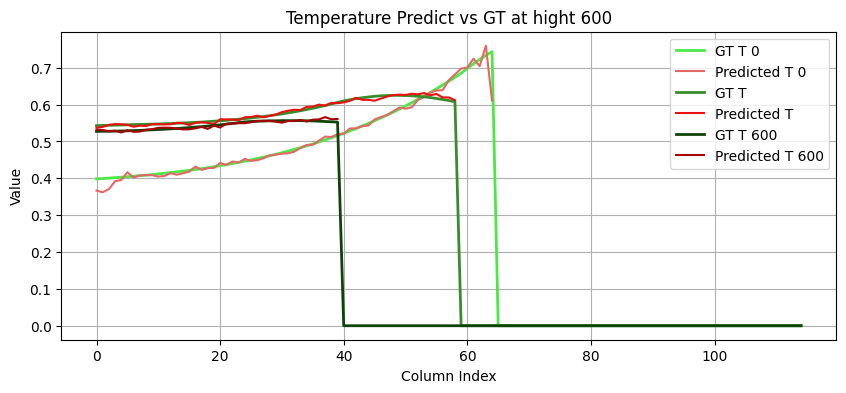

In [67]:
###cross section of data
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import os
    
    
# soot_path = os.path.join('C:/Users/User/Documents/GenerateData/GeneratedData/7025', "sootCalculation.mat")
# soot_mat = loadmat(soot_path)
# gt_t = soot_mat["T"].astype(np.float32)
# gt_fv = soot_mat["fv"].astype(np.float32)
output_path = 'C:/Users/User/Documents/Sooth_Features_Extraction_plat/Train_CNNencdec_both_2025-0623-082751'
pred_t = np.loadtxt(os.path.join(output_path, '3__7025_T_Pred.csv') , delimiter=",")
gt_t = np.loadtxt(os.path.join(output_path, '3__7025_T_GT.csv') , delimiter=",")
plt.figure(figsize=(10, 4))
row_idx = 1
rowgt = gt_t[row_idx]
# Find the last nonzero index
nonzero_indicesgt = np.flatnonzero(rowgt)
if nonzero_indicesgt.size > 0:
    last_nonzerogt = nonzero_indicesgt[-1]
    plt.plot(rowgt[:last_nonzerogt+1], color='#4CE846', label='GT T 0', linewidth=2)
else:
    plt.plot([], color='green', label='GT T')  # No nonzero data

rowp = pred_t[row_idx]
# Find the last nonzero index
nonzero_indices = np.flatnonzero(rowp)
if nonzero_indices.size > 0:
    last_nonzero = nonzero_indices[-1]
    plt.plot(rowp[:last_nonzero+1], color='#E56666', label='Predicted T 0')
else:
    plt.plot([], color='orange', label='Predicted T')  # No nonzero data

row_idx = 300
rowgt = gt_t[row_idx]
# Find the last nonzero index
nonzero_indicesgt = np.flatnonzero(rowgt)
if nonzero_indicesgt.size > 0:
    last_nonzerogt = nonzero_indicesgt[-1]
    plt.plot(rowgt[:last_nonzerogt+1], color='#358E2A', label='GT T', linewidth=2)
else:
    plt.plot([], color='green', label='GT T')  # No nonzero data

rowp = pred_t[row_idx]
# Find the last nonzero index
nonzero_indices = np.flatnonzero(rowp)
if nonzero_indices.size > 0:
    last_nonzero = nonzero_indices[-1]
    plt.plot(rowp[:last_nonzero+1], color='#ED1010', label='Predicted T')
else:
    plt.plot([], color='orange', label='Predicted T')  # No nonzero data

row_idx = 600
rowgt = gt_t[row_idx]
# Find the last nonzero index
nonzero_indicesgt = np.flatnonzero(rowgt)
if nonzero_indicesgt.size > 0:
    last_nonzerogt = nonzero_indicesgt[-1]
    plt.plot(rowgt[:last_nonzerogt+1], color='#0F4409', label='GT T 600', linewidth=2)
else:
    plt.plot([], color='green', label='GT T')  # No nonzero data

rowp = pred_t[row_idx]
# Find the last nonzero index
nonzero_indices = np.flatnonzero(rowp)
if nonzero_indices.size > 0:
    last_nonzero = nonzero_indices[-1]
    plt.plot(rowp[:last_nonzero+1], color='#A80505', label='Predicted T 600')
else:
    plt.plot([], color='orange', label='Predicted T')  # No nonzero data

plt.title(f"Temperature Predict vs GT at hight {row_idx}")
plt.xlabel("Column Index")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()



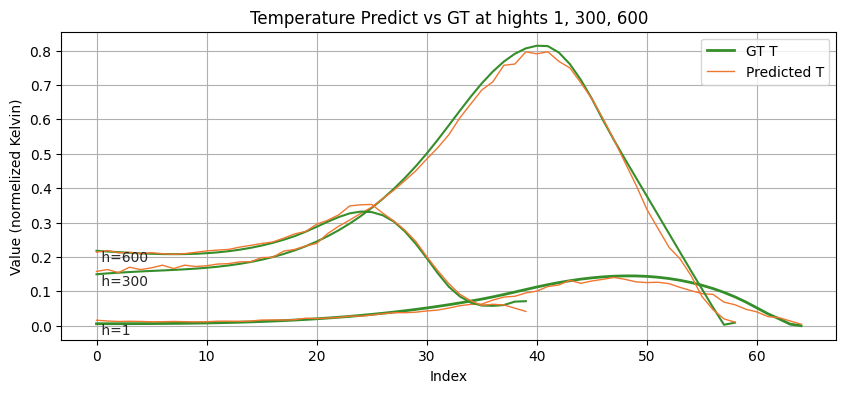

In [91]:
###cross section of data
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import os
    

output_path = 'C:/Users/User/Documents/Sooth_Features_Extraction_plat/Train_CNNencdec_both_2025-0623-082751'
pred_t = np.loadtxt(os.path.join(output_path, '3__7025_Fv_Pred.csv') , delimiter=",")
gt_t = np.loadtxt(os.path.join(output_path, '3__7025_Fv_GT.csv') , delimiter=",")
# output_path = 'C:/Users/User/Documents/Sooth_Features_Extraction_plat/SingleTest_CNNencdec_both_2025-0625-124328'
# pred_t = np.loadtxt(os.path.join(output_path, '3_3_Fv_Pred.csv') , delimiter=",")
# gt_t = np.loadtxt(os.path.join(output_path, '3_3_Fv_GT.csv') , delimiter=",")

plt.figure(figsize=(10, 4))

row_idx = 1
rowgt = gt_t[row_idx]
# Find the last nonzero index
rowp = pred_t[row_idx]
# Find the last nonzero index
nonzero_indices = np.flatnonzero(rowp)
if nonzero_indices.size > 0:
    last_nonzero = nonzero_indices[-1]
    plt.plot(rowgt[:last_nonzero+1], color='#358E2A', label='GT T', linewidth=2)    
    plt.plot(rowp[:last_nonzero+1], color='#F0762F', label='Predicted T', linewidth=1)
else:
    plt.plot([], color='green')  # No nonzero data
    plt.plot([], color='orange')  # No nonzero data
# plt.scatter(0, rowgt[0], color='darkgreen', zorder=5)
plt.text(0, rowgt[0], " h=1", va='top', color='#282726')


row_idx = 300
rowgt = gt_t[row_idx]
# Find the last nonzero index
rowp = pred_t[row_idx]
# Find the last nonzero index
nonzero_indices = np.flatnonzero(rowp)
if nonzero_indices.size > 0:
    last_nonzero = nonzero_indices[-1]
    plt.plot(rowgt[:last_nonzero+1], color='#358E2A')    
    plt.plot(rowp[:last_nonzero+1], color='#F0762F', linewidth=1)
else:
    plt.plot([], color='green')  # No nonzero data
    plt.plot([], color='orange')  # No nonzero data
plt.text(0, rowgt[0], " h=300", va='top', color='#282726')

row_idx = 600
rowgt = gt_t[row_idx]
# Find the last nonzero index
rowp = pred_t[row_idx]
# Find the last nonzero index
nonzero_indices = np.flatnonzero(rowp)
if nonzero_indices.size > 0:
    last_nonzero = nonzero_indices[-1]
    plt.plot(rowgt[:last_nonzero+1], color='#358E2A')    
    plt.plot(rowp[:last_nonzero+1], color='#F0762F', linewidth=1)
else:
    plt.plot([], color='green')  # No nonzero data
    plt.plot([], color='orange')  # No nonzero data
plt.text(0, rowgt[0], " h=600", va='top', color='#282726')

plt.title(f"Temperature Predict vs GT at hights 1, 300, 600")
plt.xlabel("Index")
plt.ylabel("Value (normelized Kelvin)")
plt.legend()
plt.grid(True)
plt.show()



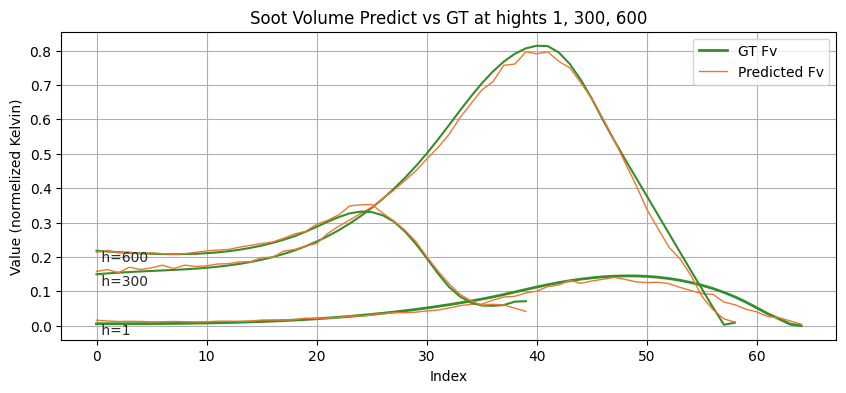

In [90]:
###cross section of data
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import os
    
    
output_path = 'C:/Users/User/Documents/Sooth_Features_Extraction_plat/Train_CNNencdec_both_2025-0623-082751'
pred_t = np.loadtxt(os.path.join(output_path, '3__7025_Fv_Pred.csv') , delimiter=",")
gt_t = np.loadtxt(os.path.join(output_path, '3__7025_Fv_GT.csv') , delimiter=",")
# output_path = 'C:/Users/User/Documents/Sooth_Features_Extraction_plat/SingleTest_CNNencdec_both_2025-0625-124328'
# pred_t = np.loadtxt(os.path.join(output_path, '3_3_Fv_Pred.csv') , delimiter=",")
# gt_t = np.loadtxt(os.path.join(output_path, '3_3_Fv_GT.csv') , delimiter=",")

plt.figure(figsize=(10, 4))

row_idx = 1
rowgt = gt_t[row_idx]
# Find the last nonzero index
rowp = pred_t[row_idx]
# Find the last nonzero index
nonzero_indices = np.flatnonzero(rowp)
if nonzero_indices.size > 0:
    last_nonzero = nonzero_indices[-1]
    plt.plot(rowgt[:last_nonzero+1], color='#358E2A', label='GT Fv', linewidth=2)    
    plt.plot(rowp[:last_nonzero+1], color='#F0762F', label='Predicted Fv', linewidth=1)
else:
    plt.plot([], color='green')  # No nonzero data
    plt.plot([], color='orange')  # No nonzero data
# plt.scatter(0, rowgt[0], color='darkgreen', zorder=5)
plt.text(0, rowgt[0], " h=1", va='top', color='#282726')


row_idx = 300
rowgt = gt_t[row_idx]
# Find the last nonzero index
rowp = pred_t[row_idx]
# Find the last nonzero index
nonzero_indices = np.flatnonzero(rowp)
if nonzero_indices.size > 0:
    last_nonzero = nonzero_indices[-1]
    plt.plot(rowgt[:last_nonzero+1], color='#358E2A')    
    plt.plot(rowp[:last_nonzero+1], color='#F0762F', linewidth=1)
else:
    plt.plot([], color='green')  # No nonzero data
    plt.plot([], color='orange')  # No nonzero data
plt.text(0, rowgt[0], " h=300", va='top', color='#282726')

row_idx = 600
rowgt = gt_t[row_idx]
# Find the last nonzero index
rowp = pred_t[row_idx]
# Find the last nonzero index
nonzero_indices = np.flatnonzero(rowp)
if nonzero_indices.size > 0:
    last_nonzero = nonzero_indices[-1]
    plt.plot(rowgt[:last_nonzero+1], color='#358E2A')    
    plt.plot(rowp[:last_nonzero+1], color='#F0762F', linewidth=1)
else:
    plt.plot([], color='green')  # No nonzero data
    plt.plot([], color='orange')  # No nonzero data
plt.text(0, rowgt[0], " h=600", va='top', color='#282726')

plt.title(f"Soot Volume Predict vs GT at hights 1, 300, 600")
plt.xlabel("Index")
plt.ylabel("Value (normelized Kelvin)")
plt.legend()
plt.grid(True)
plt.show()

